AMB2275_TANUJA SL

In [ ]:
import tensorflow as tf
#step 1:load the data set
mnist=tf.keras.datasets.mnist
(train_images,train_labels),(test_images,test_labels)=mnist.load_data()
print("train_images.shape",train_images.shape)
print("train_labels.shape",train_labels.shape)
print("test_images.shape",test_images.shape)
print("test_images.shape",test_labels.shape)


train_images.shape (60000, 28, 28)
train_labels.shape (60000,)
test_images.shape (10000, 28, 28)
test_images.shape (10000,)


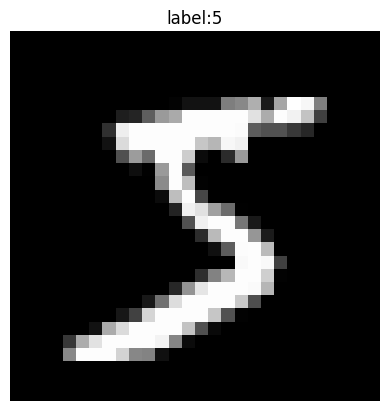

In [ ]:
import matplotlib.pyplot as plt
#plot 1st image
plt.imshow(train_images[0],cmap='gray')
plt.title(f"label:{train_labels[0]}")
plt.axis('off')
plt.show()

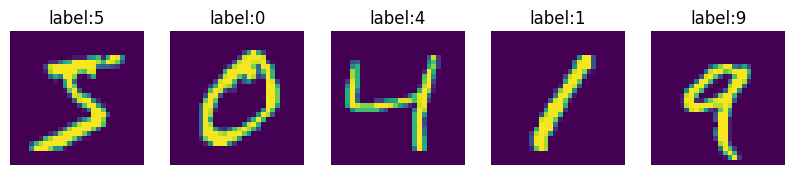

In [ ]:
#show 1st 5 images with labels
plt.figure(figsize=(10,2))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(train_images[i])
  plt.title(f"label:{train_labels[i]}")
  plt.axis('off')
plt.show()


In [ ]:
#step2 normalize values(0,9)
train_images=train_images/255.0
test_images=test_images/255.0


In [ ]:
#step 3:add channel dimension (important for CNN)
train_images=train_images.reshape((60000,28,28,1))
test_images=test_images.reshape((10000,28,28,1))
print("train_images.shape",train_images.shape)
print("test_images.shape",test_images.shape)

train_images.shape (60000, 28, 28, 1)
test_images.shape (10000, 28, 28, 1)


In [ ]:
from tensorflow.keras import layers,models
model=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(24,activation='relu'),
    layers.Dense(10,activation='softmax')
])


In [ ]:
#step5 compile model
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
#step6 train model
model.fit(train_images,train_labels,epochs=5,batch_size=64)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.9250 - loss: 0.2640
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.9742 - loss: 0.0905
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.9813 - loss: 0.0629
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.9855 - loss: 0.0493
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9879 - loss: 0.0407


In [ ]:
#step 7 test model
test_loss,test_acc=model.evaluate(test_images,test_labels)
print("test_acc",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9804 - loss: 0.0607
test_acc 0.980400025844574


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Original Label: 1
Predicted Label: 1


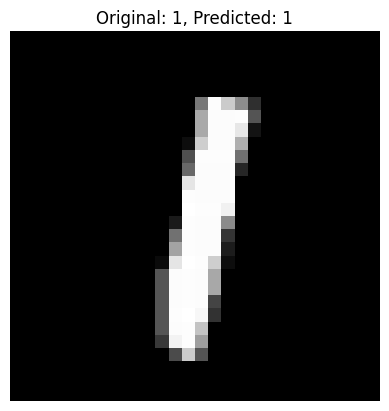

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a random index
index = np.random.randint(0, len(test_images))

# Get image and label
sample_image = test_images[index]
true_label = test_labels[index]

# Expand dimensions for model input
sample_image_input = np.expand_dims(sample_image, axis=0)

# Predict
prediction = model.predict(sample_image_input)    # gives probability from 0 to 9
predicted_label = np.argmax(prediction)           # gives the index of highest probability

# Print results
print("Original Label:", true_label)
print("Predicted Label:", predicted_label)

# Show the image
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Original: {true_label}, Predicted: {predicted_label}")
plt.axis('off')
plt.show()

In [ ]:
# Step 4: Build CNN model

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),   #convolution layer 2
    tf.keras.layers.MaxPooling2D(2,2),   #pooling layer 2

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Step 5: Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 6: Train model
model.fit(train_images, train_labels, epochs=3)
#print(model.summary())

# Step 7: Test model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9393 - loss: 0.2039
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9785 - loss: 0.0694
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9843 - loss: 0.0508
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9859 - loss: 0.0445
Accuracy: 0.9858999848365784
